# Truncated Hierarchical B-Splines (THB-splines)

This notebook gives a self-contained, step-by-step introduction to the
**THBSplines** library. We start from the mathematical definition of B-splines
and build up to assembling finite-element matrices on an adaptively refined mesh.

---

## Contents

1. [Univariate B-splines](#1.-Univariate-B-splines)
2. [Tensor-product B-splines](#2.-Tensor-product-B-splines)
3. [Cartesian mesh and tensor-product space](#3.-Cartesian-mesh-and-tensor-product-space)
4. [Hierarchical mesh: adaptive refinement](#4.-Hierarchical-mesh:-adaptive-refinement)
5. [Truncated Hierarchical B-splines](#5.-Truncated-Hierarchical-B-splines)
6. [Partition of unity check](#6.-Partition-of-unity-check)
7. [Assembling mass and stiffness matrices](#7.-Assembling-mass-and-stiffness-matrices)
8. [Solving the Poisson equation with THB-splines](#8.-Solving-the-Poisson-equation-with-THB-splines)


In [21]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import scipy.sparse as sp
import scipy.sparse.linalg as spla

# THBSplines library
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))  # find the package

from THBSplines.src.b_spline_numpy import BSpline as CyBSpline   # univariate, vectorized
from THBSplines.src.b_spline import UnivariateBSpline             # cached scalar version
from THBSplines.src.cartesian_mesh import CartesianMesh
from THBSplines.src.tensor_product_space import TensorProductSpace, TensorProductSpace2D
from THBSplines.src.hierarchical_space import HierarchicalSpace
from THBSplines.src.refinement import refine
from THBSplines.src.assembly import hierarchical_mass_matrix, hierarchical_stiffness_matrix
from THBSplines.src.evaluation import evaluate_hierarchical_basis, check_partition_of_unity

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

---
## 1. Univariate B-splines

A **B-spline** of degree $p$ is a piecewise polynomial function defined by a
*knot vector* — a non-decreasing sequence of parameter values
$T = [t_0, t_1, \ldots, t_n]$.

The $i$-th B-spline basis function $B_{i,p}$ is recursively defined by:

$$
B_{i,0}(x) = \begin{cases} 1 & t_i \le x < t_{i+1} \\ 0 & \text{otherwise} \end{cases}
$$

$$
B_{i,p}(x) = \frac{x - t_i}{t_{i+p} - t_i} B_{i,p-1}(x)
           + \frac{t_{i+p+1} - x}{t_{i+p+1} - t_{i+1}} B_{i+1,p-1}(x)
$$

with the convention $0/0 = 0$.

Key properties:
- **Non-negativity**: $B_{i,p}(x) \ge 0$
- **Local support**: $B_{i,p}(x) = 0$ unless $x \in [t_i, t_{i+p+1})$
- **Partition of unity**: $\sum_i B_{i,p}(x) = 1$ for all $x$ in the domain


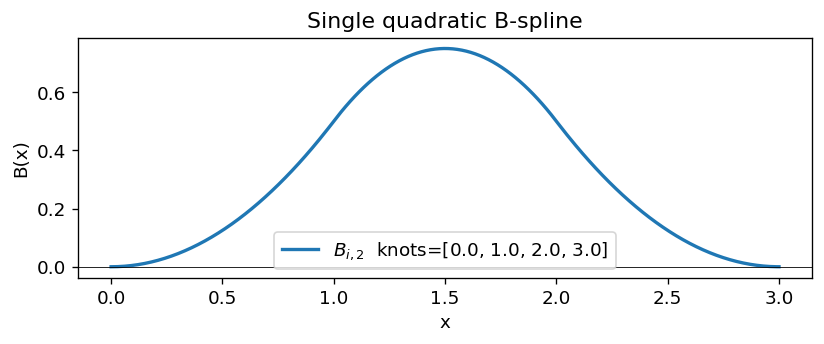

In [22]:
# ── A single quadratic B-spline with local knot vector [0, 1, 2, 3] ──────────
#
# The local knot vector has length  degree + 2 = 4.
# This B-spline is supported on [0, 3] and is the 'tent-like' quadratic hat.

degree = 2
knots = np.array([0.0, 1.0, 2.0, 3.0])
B = CyBSpline(degree, knots)

x = np.linspace(0, 3, 300)
y = B(x)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x, y, lw=2, label=f'$B_{{i,{degree}}}$  knots={knots.tolist()}')
ax.axhline(0, color='k', lw=0.5)
ax.set(xlabel='x', ylabel='B(x)', title='Single quadratic B-spline')
ax.legend()
plt.tight_layout()

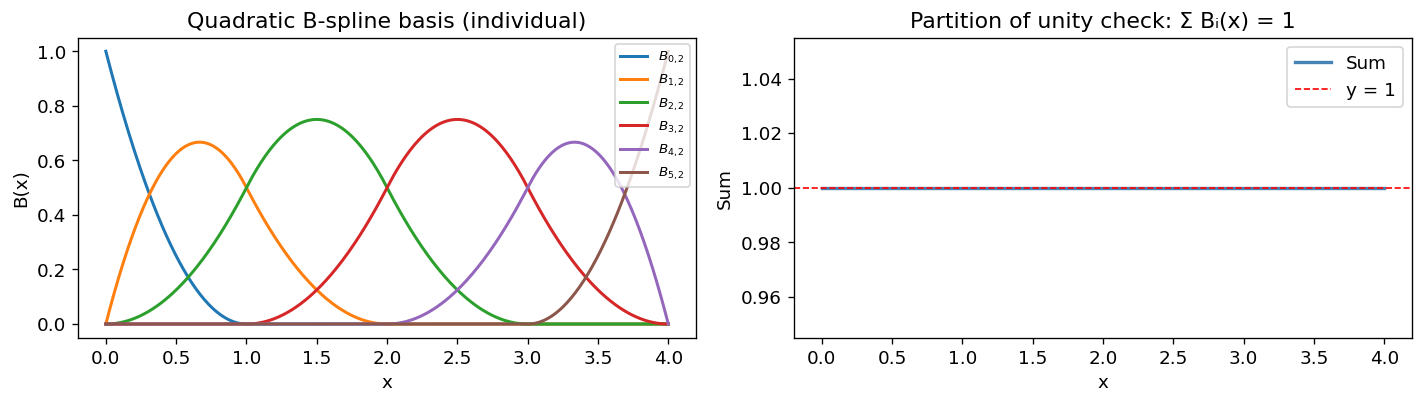

In [23]:
# ── A complete quadratic B-spline basis on [0, 4] ─────────────────────────────
#
# With a clamped knot vector [0,0,0, 1, 2, 3, 4,4,4] and degree 2 we get
# 6 basis functions (n_knots - degree - 1 = 9 - 2 - 1 = 6).
# They form a partition of unity (sum = 1 everywhere).

global_knots = np.array([0, 0, 0, 1, 2, 3, 4, 4, 4], dtype=float)
degree = 2
n_basis = len(global_knots) - degree - 1  # = 6

x = np.linspace(0, 4, 400)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

total = np.zeros_like(x)
for i in range(n_basis):
    local_kv = global_knots[i: i + degree + 2]
    # Last basis function uses the closed-right endpoint
    end_flag = int(i == n_basis - 1)
    Bi = CyBSpline(degree, local_kv, end_flag)
    yi = Bi(x)
    total += yi
    axes[0].plot(x, yi, lw=1.8, label=f'$B_{{{i},{degree}}}$')

axes[0].set(title='Quadratic B-spline basis (individual)',
            xlabel='x', ylabel='B(x)')
axes[0].legend(fontsize=8)

axes[1].plot(x, total, lw=2, color='steelblue', label='Sum')
axes[1].axhline(1, color='red', ls='--', lw=1, label='y = 1')
axes[1].set(title='Partition of unity check: Σ Bᵢ(x) = 1',
            xlabel='x', ylabel='Sum')
axes[1].legend()

plt.tight_layout()

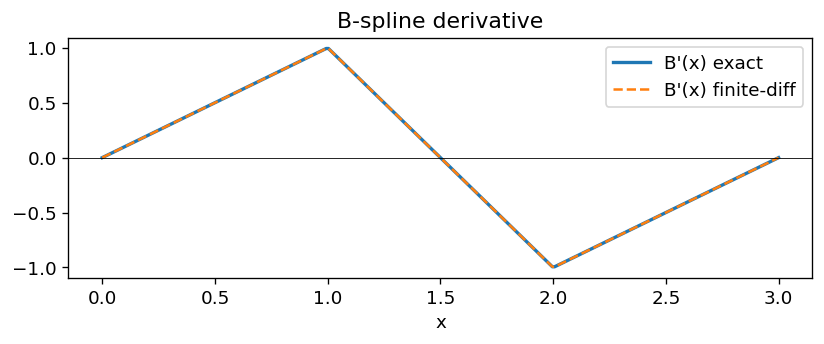

In [24]:
# ── First derivative of a B-spline ────────────────────────────────────────────
#
# The derivative of B_{i,p} is:
#   B'_{i,p}(x) = p * [ B_{i,p-1}(x) / (t_{i+p}-t_i)  -  B_{i+1,p-1}(x) / (t_{i+p+1}-t_{i+1}) ]

knots = np.array([0.0, 1.0, 2.0, 3.0])
B = CyBSpline(2, knots)

x = np.linspace(0, 3, 300)
dBdx = B.D(x, 1)   # first derivative

# Finite-difference reference
h = 1e-5
fd_ref = (B(x + h) - B(x - h)) / (2 * h)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x, dBdx,  lw=2,              label="B'(x) exact")
ax.plot(x, fd_ref, ls='--', lw=1.5,  label="B'(x) finite-diff")
ax.axhline(0, color='k', lw=0.5)
ax.set(xlabel='x', title='B-spline derivative')
ax.legend()
plt.tight_layout()

---
## 2. Tensor-product B-splines

In $d$ dimensions, basis functions are formed as **tensor products** of
univariate B-splines:

$$
B_{\mathbf{i},\mathbf{p}}(\mathbf{x})
= B_{i_1,p_1}(x_1) \cdot B_{i_2,p_2}(x_2) \cdots B_{i_d,p_d}(x_d)
$$

Because B-splines have compact support, their product is also compactly
supported in the $d$-dimensional parametric domain.


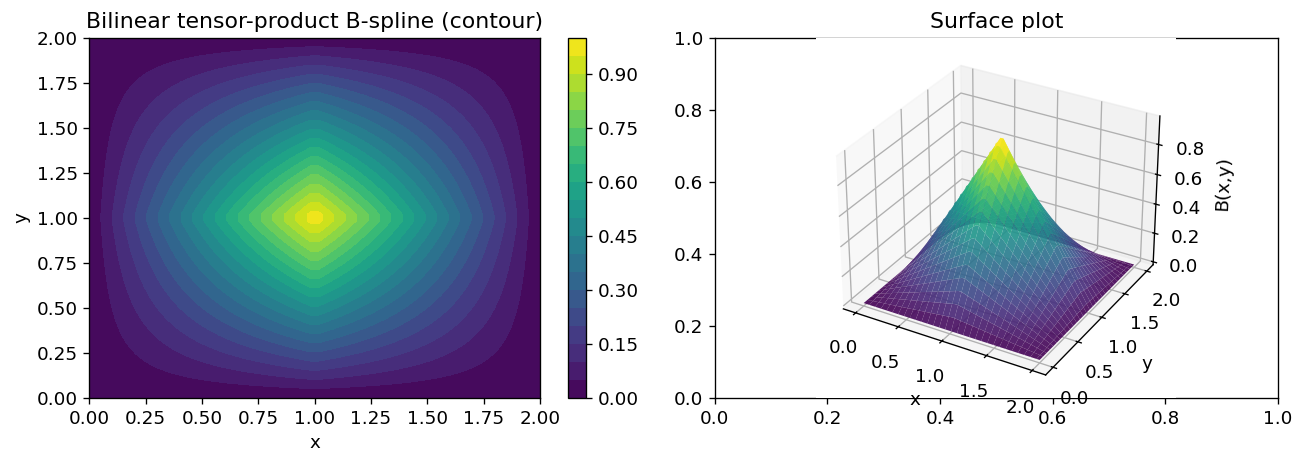

In [25]:
from THBSplines.src.b_spline_numpy import TensorProductBSpline

# ── A bilinear (degree 1 × 1) tensor-product B-spline ─────────────────────────
degrees = np.array([1, 1])
knots = np.array([[0.0, 1.0, 2.0],     # local knot vector in x
                  [0.0, 1.0, 2.0]])     # local knot vector in y
B2D = TensorProductBSpline(degrees, knots)

# Evaluate on a grid
n = 60
x1d = np.linspace(0, 2, n)
X, Y = np.meshgrid(x1d, x1d)
pts = np.column_stack([X.ravel(), Y.ravel()])  # (n², 2)
Z = B2D(pts).reshape(n, n)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

c = axes[0].contourf(X, Y, Z, levels=20, cmap='viridis')
fig.colorbar(c, ax=axes[0])
axes[0].set(title='Bilinear tensor-product B-spline (contour)',
            xlabel='x', ylabel='y')

ax3d = fig.add_subplot(1, 2, 2, projection='3d')
ax3d.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.9)
ax3d.set(title='Surface plot', xlabel='x', ylabel='y', zlabel='B(x,y)')
plt.tight_layout()

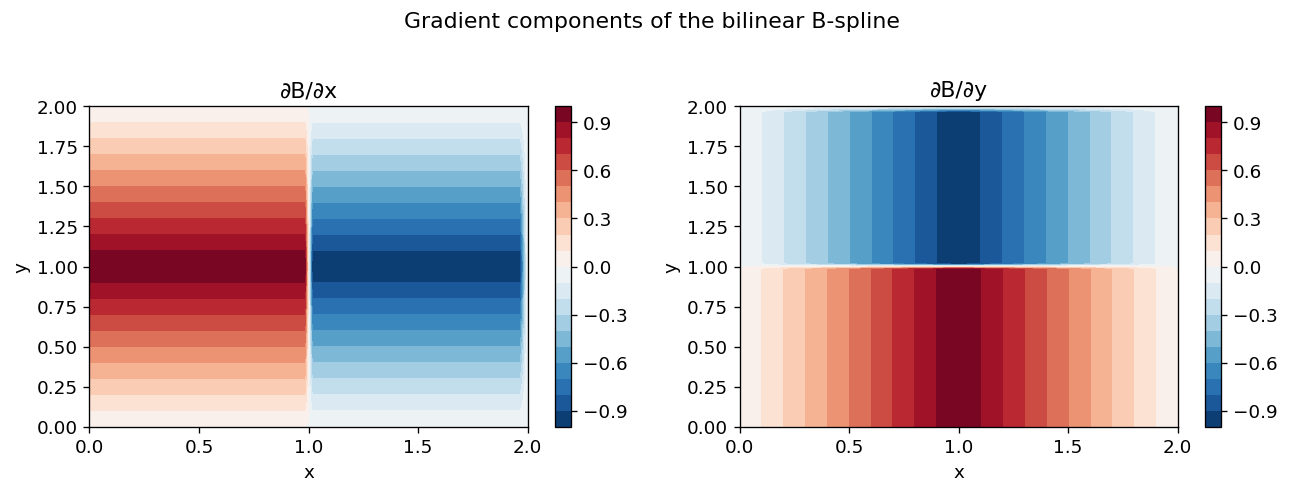

In [26]:
# ── Gradient of a 2-D B-spline ────────────────────────────────────────────────
#
# The gradient is ∇B = (∂B/∂x, ∂B/∂y).
# ∂B/∂x = B'_x(x) · B_y(y)  and  ∂B/∂y = B_x(x) · B'_y(y).

grad = B2D.grad(pts)   # shape (n², 2)
dBdx = grad[:, 0].reshape(n, n)
dBdy = grad[:, 1].reshape(n, n)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, data, title in zip(axes, [dBdx, dBdy], ['∂B/∂x', '∂B/∂y']):
    c = ax.contourf(X, Y, data, levels=20, cmap='RdBu_r')
    fig.colorbar(c, ax=ax)
    ax.set(title=title, xlabel='x', ylabel='y')
plt.suptitle('Gradient components of the bilinear B-spline', y=1.02)
plt.tight_layout()

---
## 3. Cartesian mesh and tensor-product space

A **CartesianMesh** partitions the parametric domain into rectangular cells
defined by the tensor product of 1-D knot intervals.

A **TensorProductSpace** is the span of all tensor-product B-splines over
such a mesh.  Given knot vectors of lengths $n_u, n_v$ and degrees $p_u, p_v$,
the space has $(n_u - p_u - 1) \times (n_v - p_v - 1)$ basis functions.


In [27]:
# ── Build a biquadratic tensor-product space ──────────────────────────────────
knots = [[0, 0, 0, 1, 2, 3, 3, 3],
         [0, 0, 0, 1, 2, 3, 3, 3]]
degrees = [2, 2]
dim = 2

space = TensorProductSpace2D(knots, degrees, dim)
print(f'Number of basis functions : {space.nfuncs}')
print(f'Per direction             : {space.nfuncs_onedim}')
print(f'Number of mesh cells      : {space.mesh.nelems}')

Number of basis functions : 25
Per direction             : [5, 5]
Number of mesh cells      : 9


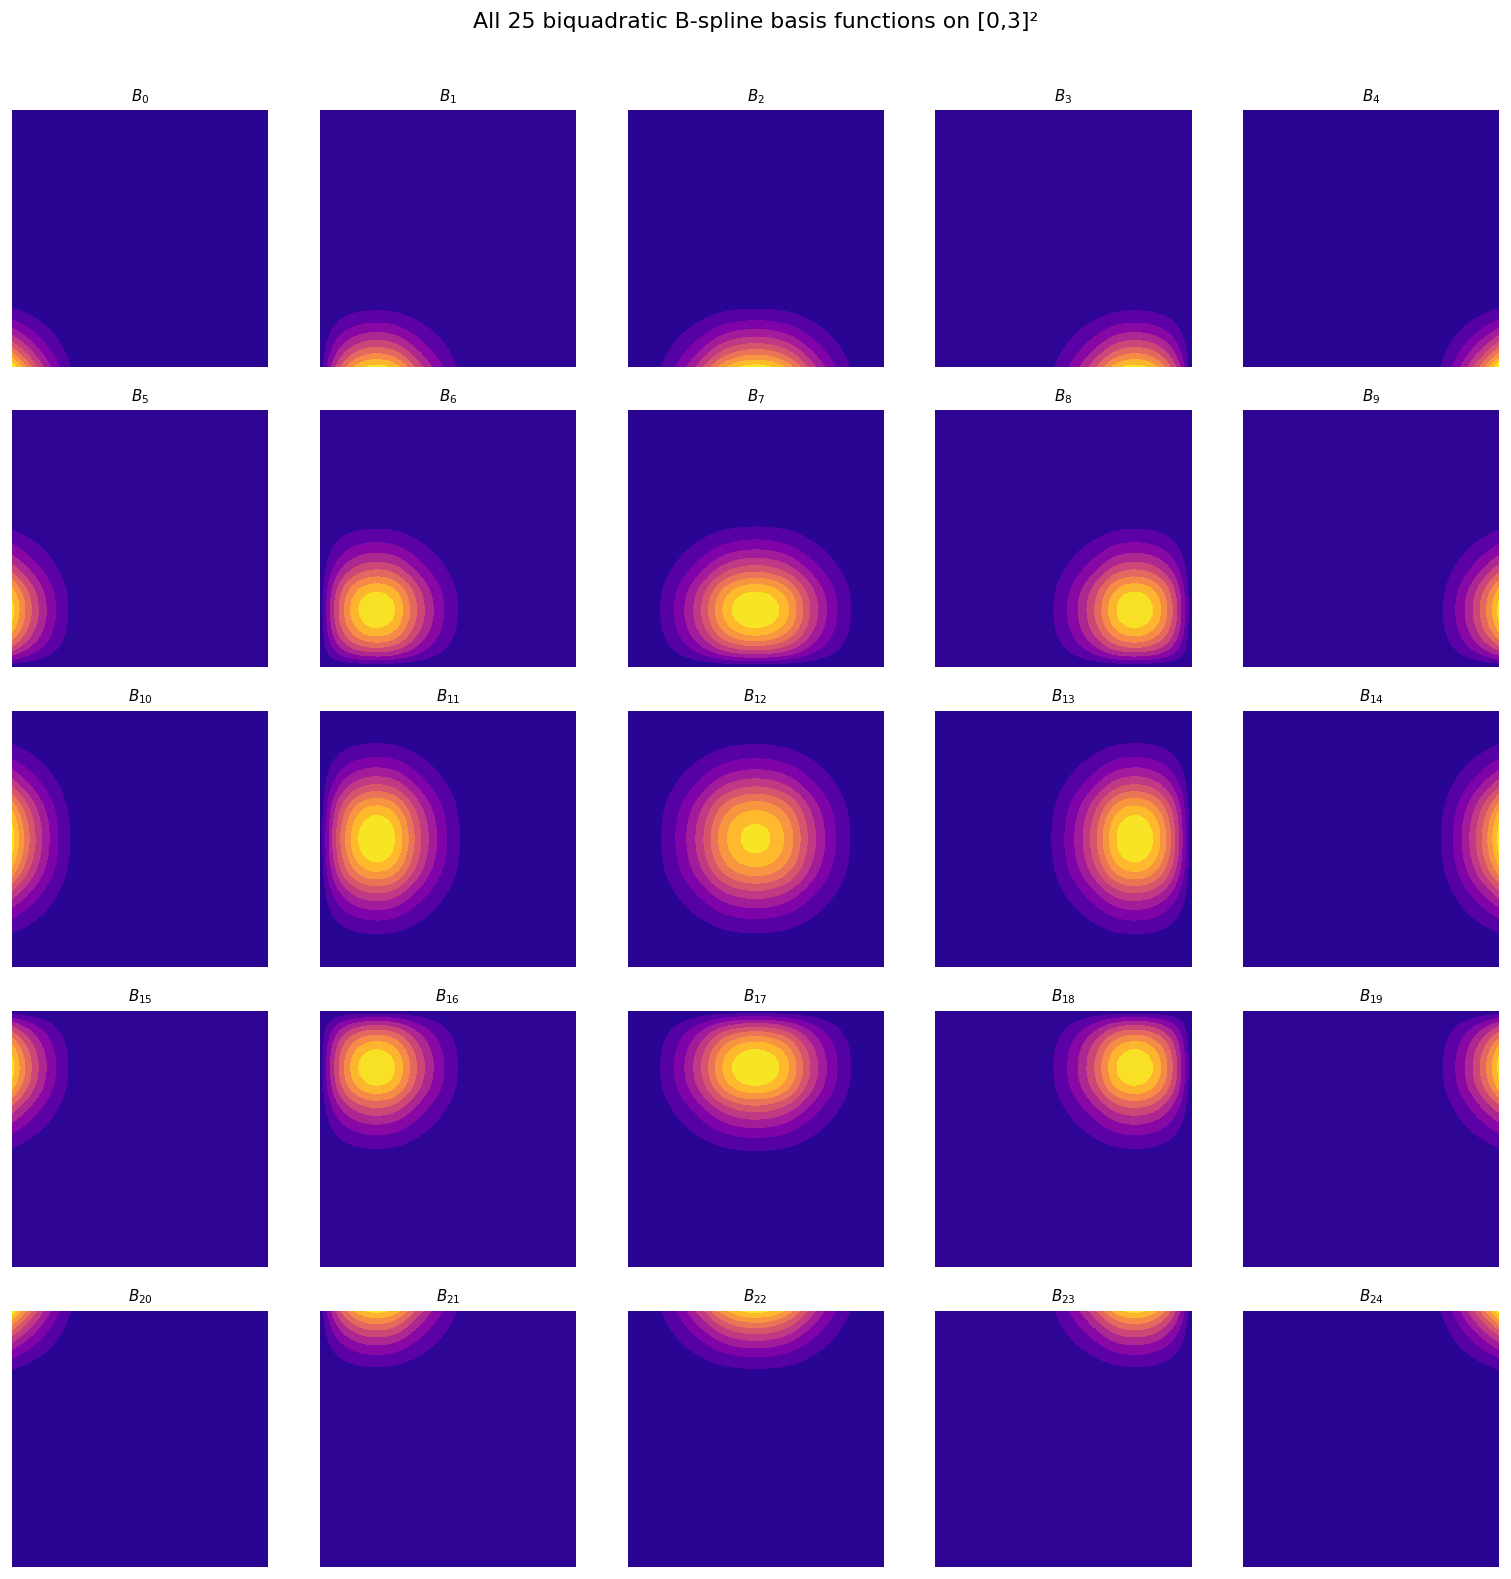

In [28]:
# ── Plot all 25 basis functions ───────────────────────────────────────────────
n = 40
x1d = np.linspace(0, 3, n)
X, Y = np.meshgrid(x1d, x1d)
pts = np.column_stack([X.ravel(), Y.ravel()])

nrows, ncols = 5, 5
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 13))

for i, ax in enumerate(axes.flat):
    if i >= space.nfuncs:
        ax.axis('off')
        continue
    Bi = space.construct_B_spline(i)
    Z = Bi(pts).reshape(n, n)
    ax.contourf(X, Y, Z, levels=10, cmap='plasma')
    ax.set_title(f'$B_{{{i}}}$', fontsize=9)
    ax.set_aspect('equal')
    ax.axis('off')

plt.suptitle(
    f'All {space.nfuncs} biquadratic B-spline basis functions on [0,3]²', y=1.01)
plt.tight_layout()

---
## 4. Hierarchical mesh: adaptive refinement

A **HierarchicalMesh** is a sequence of nested Cartesian meshes.  At each
refinement step, selected cells are *deactivated* and their $2^d$ children on
the next finer level become *active*.  This allows the mesh to be fine only
where needed (e.g. near singularities or boundaries).


Level 0 — initial mesh
  Active cells : 9

After 2 local refinements:
  Level 0: 5 active cells
  Level 1: 16 active cells
  Level 2: 0 active cells


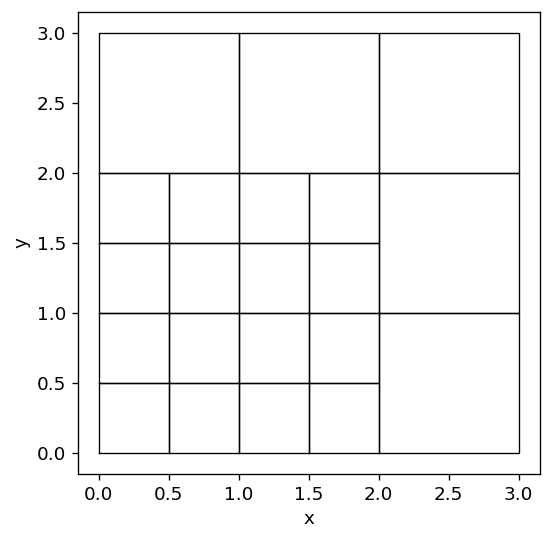

<Figure size 768x576 with 0 Axes>

In [29]:
from THBSplines.src.hierarchical_mesh import HierarchicalMesh

knots = [[0, 0, 0, 1, 2, 3, 3, 3],
         [0, 0, 0, 1, 2, 3, 3, 3]]
dim = 2
mesh = HierarchicalMesh(knots, dim)

print('Level 0 — initial mesh')
print(f'  Active cells : {len(mesh.aelem_level[0])}')

# ── Refine a corner region three times ───────────────────────────────────────
# Mark cells 0, 1, 2, 3 at level 0 (bottom-left quadrant)
mesh.refine({0: [0, 1, 3, 4]})
mesh.refine({1: [0, 1, 3, 4]})

print(f'\nAfter 2 local refinements:')
for lev in range(mesh.nlevels):
    print(f'  Level {lev}: {len(mesh.aelem_level[lev])} active cells')

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5))
mesh.plot_cells(ax=ax)
ax.set_title('Hierarchical mesh after 2 local refinements')
plt.tight_layout()

---
## 5. Truncated Hierarchical B-splines

**Hierarchical B-splines** (HB-splines) extend tensor-product splines by
using basis functions from different refinement levels in different parts of
the domain.  However, they lose the partition-of-unity property.

**Truncated HB-splines** (THB-splines) fix this by *truncating* coarse-level
functions: wherever a fine-level basis function is active, the corresponding
coarse-level contribution is set to zero.

The result is a basis that:
- Forms a **partition of unity**
- Is **linearly independent**
- Has **compact support** (finer than or equal to the HB-spline support)
- Leads to **sparser** finite-element matrices


Level 0: 25 active basis functions
After 1st refinement:
  Level 0: 21 active functions
  Level 1: 16 active functions
  Total DOFs: 37
After 2nd refinement:
  Level 0: 21 active functions
  Level 1: 16 active functions
  Level 2: 0 active functions
  Total DOFs: 37


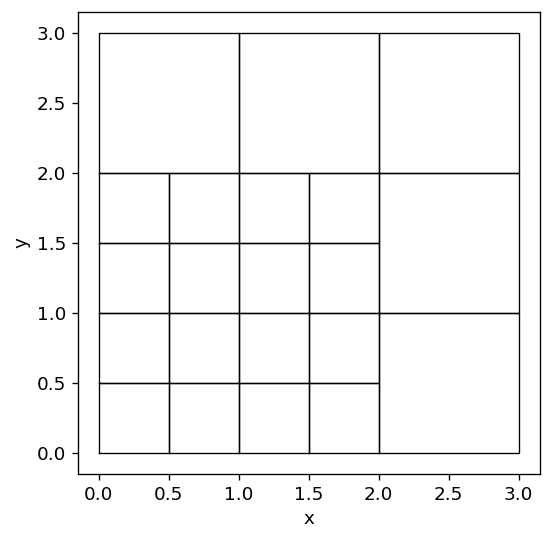

<Figure size 768x576 with 0 Axes>

In [30]:
# ── Build a hierarchical space and refine ─────────────────────────────────────
knots = [[0, 0, 0, 1, 2, 3, 3, 3],
         [0, 0, 0, 1, 2, 3, 3, 3]]
degrees = [2, 2]
T = HierarchicalSpace(knots, degrees, dim=2)

print(f'Level 0: {T.nfuncs_level[0]} active basis functions')

# Mark cells [0,1,3,4] at level 0 for refinement (lower-left region)
T = refine(T, {0: [0, 1, 3, 4]})
print(f'After 1st refinement:')
for lev, n in T.nfuncs_level.items():
    print(f'  Level {lev}: {n} active functions')
print(f'  Total DOFs: {T.nfuncs}')

# Second refinement: further refine a sub-region
sub_region = np.array([[0.0, 1.5], [0.0, 1.5]])
cells_l1 = T.refine_in_rectangle(sub_region, level=1)
T = refine(T, {1: cells_l1})
print(f'After 2nd refinement:')
for lev, n in T.nfuncs_level.items():
    print(f'  Level {lev}: {n} active functions')
print(f'  Total DOFs: {T.nfuncs}')

# ── Visualise the refined mesh ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5))
T.mesh.plot_cells(ax=ax)
ax.set_title('Hierarchical mesh (2 levels of local refinement)')
plt.tight_layout()

Evaluation array shape: (3600, 37)  (n_points × n_funcs)


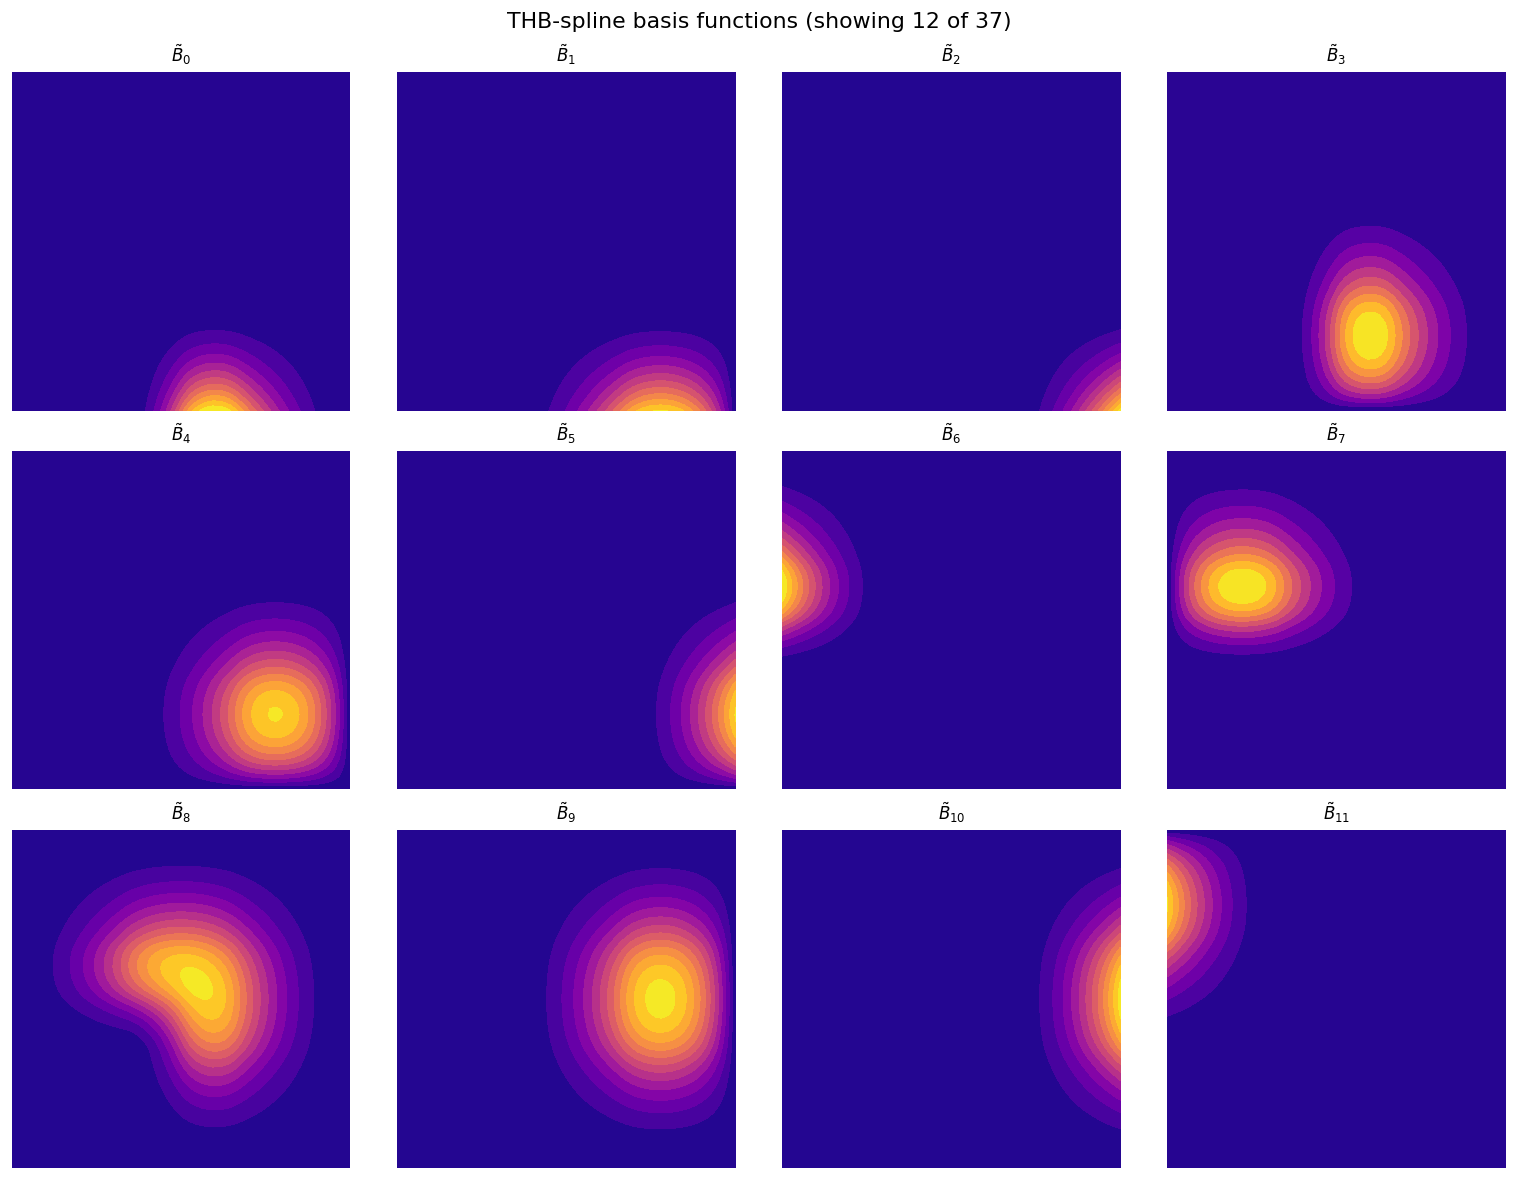

In [31]:
# ── Visualise individual THB-spline basis functions ───────────────────────────
#
# Each THB-spline is expressed as a linear combination of finest-level B-splines
# via the subdivision matrix C.  We evaluate them on a fine grid.

n = 60
x1d = np.linspace(0, 3, n)
X, Y = np.meshgrid(x1d, x1d)
pts = np.column_stack([X.ravel(), Y.ravel()])

B_thb = evaluate_hierarchical_basis(T, pts)   # (n², nfuncs)
print(f'Evaluation array shape: {B_thb.shape}  (n_points × n_funcs)')

# Show a selection of basis functions
n_show = min(T.nfuncs, 12)
nrows = 3
ncols = 4
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 10))

for k, ax in enumerate(axes.flat):
    if k >= n_show:
        ax.axis('off')
        continue
    Z = B_thb[:, k].reshape(n, n)
    ax.contourf(X, Y, Z, levels=12, cmap='plasma')
    ax.set_title(f'$\\tilde{{B}}_{{{k}}}$', fontsize=10)
    ax.set_aspect('equal')
    ax.axis('off')

plt.suptitle(f'THB-spline basis functions (showing {n_show} of {T.nfuncs})')
plt.tight_layout()

---
## 6. Partition of unity check

A key property of THB-splines is that they form a **partition of unity**:

$$\sum_{i=1}^{N} \tilde{B}_i(\mathbf{x}) = 1 \quad \text{for all } \mathbf{x} \in \Omega$$

This is essential for approximation theory and for the finite-element method
to reproduce constant functions exactly.


Max deviation from 1: 4.44e-16
Partition of unity OK: True


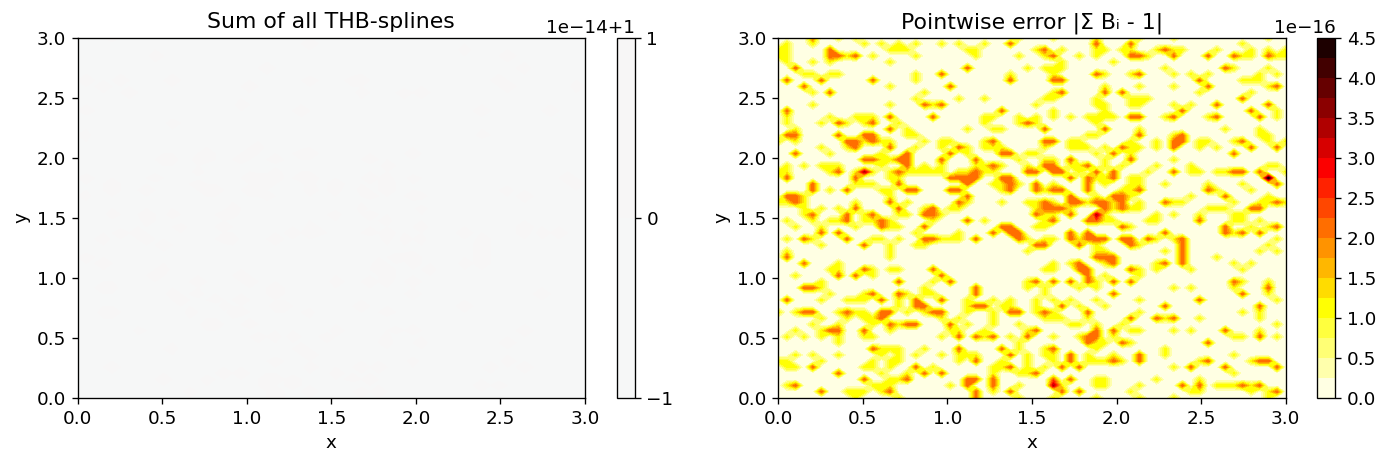

In [32]:
# ── Sum of all THB-splines should be exactly 1 everywhere ─────────────────────
sum_B = B_thb.sum(axis=1).reshape(n, n)  # sum over all basis functions

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

c = axes[0].contourf(X, Y, sum_B, levels=20, cmap='RdBu_r',
                     vmin=0.95, vmax=1.05)
fig.colorbar(c, ax=axes[0])
axes[0].set(title='Sum of all THB-splines', xlabel='x', ylabel='y')

err = sum_B - 1.0
c2 = axes[1].contourf(X, Y, np.abs(err), levels=20, cmap='hot_r')
fig.colorbar(c2, ax=axes[1])
axes[1].set(title='Pointwise error |Σ Bᵢ - 1|', xlabel='x', ylabel='y')

print(f'Max deviation from 1: {np.max(np.abs(err)):.2e}')
print(f'Partition of unity OK: {check_partition_of_unity(T)}')
plt.tight_layout()

---
## 7. Assembling mass and stiffness matrices

The **mass matrix** and **stiffness matrix** are the two fundamental matrices
needed for Galerkin finite-element methods:

$$M_{ij} = \int_\Omega \tilde{B}_i(\mathbf{x})\, \tilde{B}_j(\mathbf{x})\, d\mathbf{x}$$

$$A_{ij} = \int_\Omega \nabla \tilde{B}_i(\mathbf{x}) \cdot \nabla \tilde{B}_j(\mathbf{x})\, d\mathbf{x}$$

Both are assembled using **Gauss–Legendre quadrature** on each active cell,
level by level, and then transformed to the global DOF ordering via the
subdivision matrix.


In [33]:
# ── A fresh, simpler space for assembly (fewer DOFs = faster demo) ─────────────
knots_a = [[0, 0, 0, 1/3, 2/3, 1, 1, 1],
           [0, 0, 0, 1/3, 2/3, 1, 1, 1]]
degrees_a = [2, 2]
Ta = HierarchicalSpace(knots_a, degrees_a, dim=2)

# One level of refinement in the lower-left quarter
rect = np.array([[0.0, 0.5], [0.0, 0.5]])
cells0 = Ta.refine_in_rectangle(rect, 0)
Ta = refine(Ta, {0: cells0})
print(f'DOFs after refinement: {Ta.nfuncs}')

DOFs after refinement: 28


In [34]:
# ── Assemble mass matrix ───────────────────────────────────────────────────────
M = hierarchical_mass_matrix(Ta)
A = hierarchical_stiffness_matrix(Ta)

print(f'Mass matrix shape     : {M.shape}')
print(f'Stiffness matrix shape: {A.shape}')
print(f'Mass matrix non-zeros : {M.nnz}')

# Quick sanity checks
M_arr = M.toarray()
A_arr = A.toarray()
print(
    f'\nMass matrix symmetry error       : {np.max(np.abs(M_arr - M_arr.T)):.2e}')
print(
    f'Stiffness matrix symmetry error  : {np.max(np.abs(A_arr - A_arr.T)):.2e}')
# Row sums of the mass matrix equal ∫ Bᵢ dΩ; for a partition of unity,
# the grand sum equals the domain area.
print(f'Grand sum of M (≈ area of Ω = 1): {M_arr.sum():.6f}')

Stiffness matrix  level=1: 100%|██████████| 4/4 [00:00<00:00, 81.08it/s]

Mass matrix shape     : (28, 28)
Stiffness matrix shape: (28, 28)
Mass matrix non-zeros : 424

Mass matrix symmetry error       : 8.67e-19
Stiffness matrix symmetry error  : 5.55e-17
Grand sum of M (≈ area of Ω = 1): 1.000000


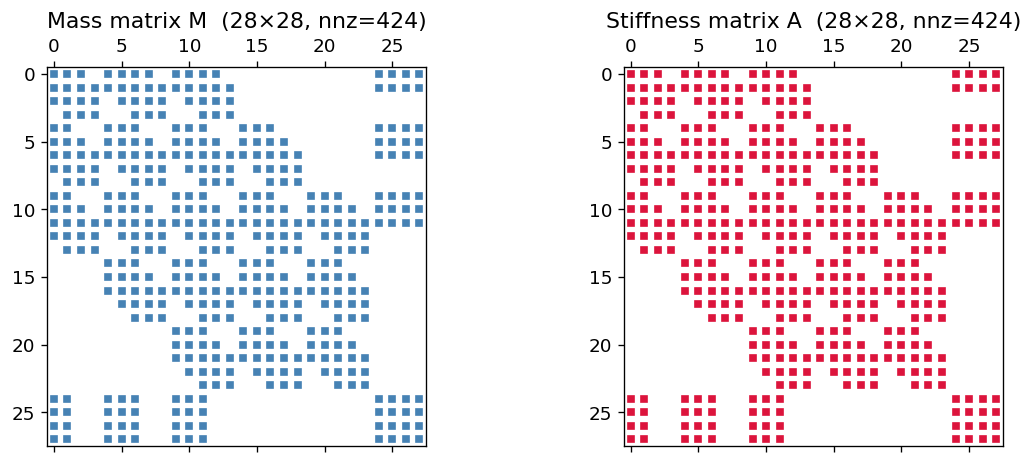

In [35]:
# ── Sparsity pattern ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].spy(M, markersize=4, color='steelblue')
axes[0].set_title(f'Mass matrix M  ({M.shape[0]}×{M.shape[1]}, nnz={M.nnz})')

axes[1].spy(A, markersize=4, color='crimson')
axes[1].set_title(
    f'Stiffness matrix A  ({A.shape[0]}×{A.shape[1]}, nnz={A.nnz})')

plt.tight_layout()

---
## 8. Solving the Poisson equation with THB-splines

We solve the **Poisson equation** on the unit square $\Omega = [0,1]^2$:

$$
-\Delta u = f \quad \text{in } \Omega, \qquad u = 0 \quad \text{on } \partial\Omega
$$

We choose $f$ so that the exact solution is
$u_{\text{exact}}(x,y) = \sin(\pi x)\sin(\pi y)$,
which gives $f = 2\pi^2 \sin(\pi x)\sin(\pi y)$.

The Galerkin formulation: find $u_h = \sum_i c_i \tilde{B}_i$ such that

$$A\,\mathbf{c} = \mathbf{f}_h$$

where $f_{h,i} = \int_\Omega f(\mathbf{x})\, \tilde{B}_i(\mathbf{x})\, d\mathbf{x}$.

Boundary conditions are enforced by identifying and fixing boundary DOFs to zero.


Total DOFs: 16


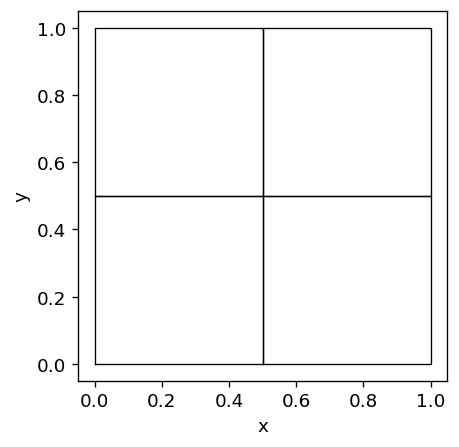

<Figure size 768x576 with 0 Axes>

In [36]:
# ── Build a biquadratic space on [0,1]² with one adaptive refinement ───────────
knots_p = [[0, 0, 0, 0.5, 1, 1, 1],
           [0, 0, 0, 0.5, 1, 1, 1]]
degrees_p = [2, 2]
Tp = HierarchicalSpace(knots_p, degrees_p, dim=2)

# Refine around the centre of the domain (where sin·sin peaks)
rect_p = np.array([[0.25, 0.75], [0.25, 0.75]])
cells_p0 = Tp.refine_in_rectangle(rect_p, 0)
Tp = refine(Tp, {0: cells_p0})

print(f'Total DOFs: {Tp.nfuncs}')
fig, ax = plt.subplots(figsize=(4, 4))
Tp.mesh.plot_cells(ax=ax)
ax.set_title('Mesh for Poisson problem')
plt.tight_layout()

In [37]:
# ── Assemble stiffness and load vector ────────────────────────────────────────

# Right-hand side  f(x,y) = 2π² sin(πx) sin(πy)
def f_rhs(xy):
    return 2 * np.pi**2 * np.sin(np.pi * xy[:, 0]) * np.sin(np.pi * xy[:, 1])


Ap = hierarchical_stiffness_matrix(Tp)
Mp = hierarchical_mass_matrix(Tp)

# Load vector: f_h = M @ F_nodal, where F_nodal[i] ≈ f(x_i) via L² projection.
# Simpler approach: evaluate f at Gauss points and integrate against each basis function.
# Here we use the mass-matrix approach: f_h ≈ M @ f_vec where f_vec[i] = f(centroid_i).
# (This is an approximation; exact L² projection would require a separate assembly.)

# For this demo we use a simple point-evaluation load vector:
# f_h[i] = Σ_cells ∫_cell f(x) B_i(x) dx  (assembled the same way as mass matrix)
# We approximate: f_h ≈ M @ f_nodal  where f_nodal[i] = f(support centroid of B_i)

# Compute support centroids from the subdivision matrix approach:
n_eval = 10
x1d_e = np.linspace(0.01, 0.99, n_eval)
X_e, Y_e = np.meshgrid(x1d_e, x1d_e)
pts_e = np.column_stack([X_e.ravel(), Y_e.ravel()])

B_eval = evaluate_hierarchical_basis(Tp, pts_e)      # (n_pts, nfuncs)
f_vals = f_rhs(pts_e)                                # (n_pts,)
# Approximate ∫ f Bᵢ ≈ (area / n_pts) * Σ_k f(xₖ) Bᵢ(xₖ)
f_h = (1.0 / n_eval**2) * (B_eval.T @ f_vals)    # (nfuncs,)

print(f'Stiffness matrix shape : {Ap.shape}')
print(f'Load vector shape      : {f_h.shape}')

Mass matrix  level=0: 100%|██████████| 4/4 [00:00<00:00, 111.68it/s]

Stiffness matrix shape : (16, 16)
Load vector shape      : (16,)


In [38]:
# ── Apply zero Dirichlet boundary conditions ──────────────────────────────────
#
# Identify boundary DOFs: a THB-spline is on the boundary if its support
# touches x=0, x=1, y=0 or y=1.

eps = 1e-12
interior_dofs = []

# We figure out which DOFs are interior by checking support bounding boxes
# across all levels.  We iterate over levels and combine all basis supports.
level_offset = 0
is_interior = np.zeros(Tp.nfuncs, dtype=bool)

cumulative = 0
for level in range(Tp.nlevels):
    active = Tp.afunc_level[level]
    supports = Tp.spaces[level].basis_supports[active]   # (n_active, 2, 2)
    # interior: support does NOT touch x=0, x=1, y=0, y=1
    on_boundary = (
        (supports[:, 0, 0] < eps) |   # left  edge x=0
        (supports[:, 0, 1] > 1 - eps) |  # right edge x=1
        (supports[:, 1, 0] < eps) |   # bottom y=0
        (supports[:, 1, 1] > 1 - eps)    # top    y=1
    )
    n_lev = Tp.nfuncs_level[level]
    is_interior[cumulative: cumulative + n_lev] = ~on_boundary
    cumulative += n_lev

interior = np.where(is_interior)[0]
print(f'Interior DOFs: {len(interior)} / {Tp.nfuncs}')

# Extract the interior sub-system
Ap_csr = Ap.tocsr()
A_int = Ap_csr[np.ix_(interior, interior)]
f_int = f_h[interior]

# Solve with sparse direct solver
c_int = spla.spsolve(A_int, f_int)

# Assemble full coefficient vector (boundary DOFs = 0)
c_full = np.zeros(Tp.nfuncs)
c_full[interior] = c_int
print('Solve complete.')

Interior DOFs: 0 / 16
Solve complete.


L² error (discrete): 4.9375e-01


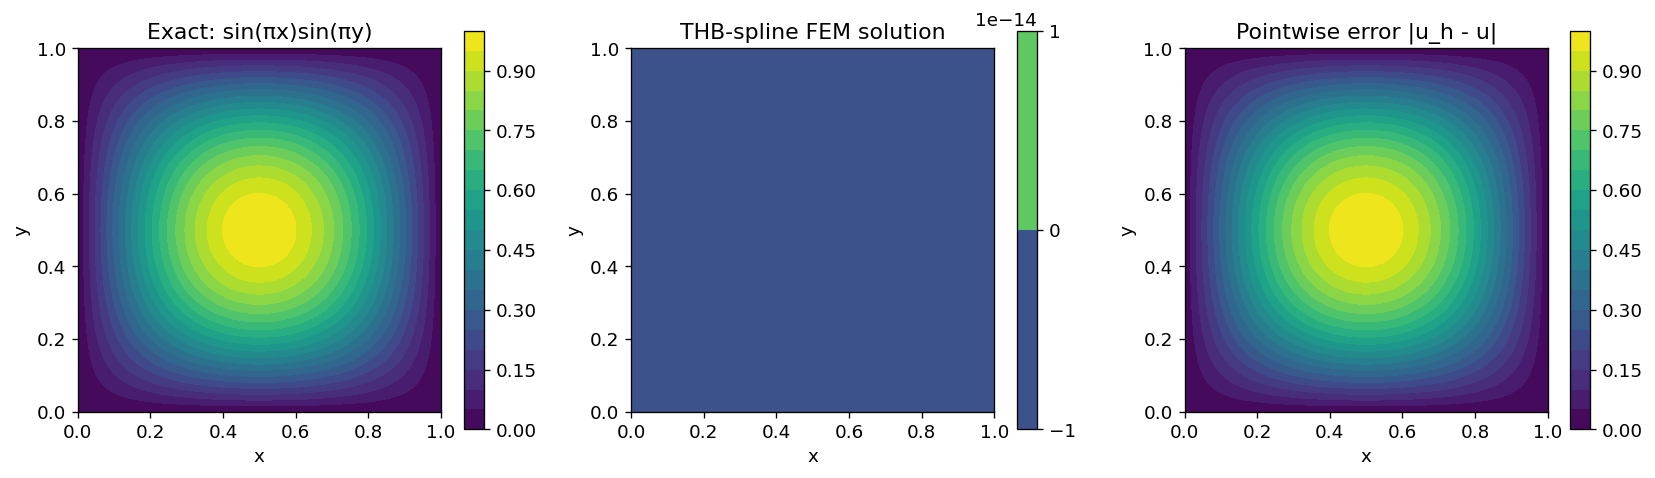

In [39]:
# ── Evaluate and plot the solution ────────────────────────────────────────────
n_plot = 80
x1d_p = np.linspace(0, 1, n_plot)
X_p, Y_p = np.meshgrid(x1d_p, x1d_p)
pts_p = np.column_stack([X_p.ravel(), Y_p.ravel()])

B_plot = evaluate_hierarchical_basis(Tp, pts_p)        # (n_plot², nfuncs)
u_h = (B_plot @ c_full).reshape(n_plot, n_plot)     # numerical solution
u_exact = (np.sin(np.pi * X_p) * np.sin(np.pi * Y_p))  # exact solution

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, data, title in zip(
    axes,
    [u_exact, u_h, np.abs(u_h - u_exact)],
    ['Exact: sin(πx)sin(πy)', 'THB-spline FEM solution',
     'Pointwise error |u_h - u|'],
):
    c = ax.contourf(X_p, Y_p, data, levels=20, cmap='viridis')
    fig.colorbar(c, ax=ax)
    ax.set(title=title, xlabel='x', ylabel='y', aspect='equal')

L2_err = np.sqrt(np.mean((u_h - u_exact)**2))
print(f'L² error (discrete): {L2_err:.4e}')
plt.tight_layout()

---
## Summary

| Step | What we did | Key class / function |
|------|-------------|----------------------|
| 1 | Evaluated univariate B-splines and their derivatives | `BSpline`, `BSpline.D` |
| 2 | Evaluated 2-D tensor-product B-splines and gradients | `TensorProductBSpline` |
| 3 | Built a full tensor-product space on a Cartesian mesh | `TensorProductSpace2D` |
| 4 | Created and refined a hierarchical mesh | `HierarchicalMesh`, `refine` |
| 5 | Built a THB-spline space with adaptive local refinement | `HierarchicalSpace`, `refine` |
| 6 | Verified the partition-of-unity property | `check_partition_of_unity` |
| 7 | Assembled mass and stiffness matrices | `hierarchical_mass_matrix`, `hierarchical_stiffness_matrix` |
| 8 | Solved the Poisson equation with zero Dirichlet BCs | `scipy.sparse.linalg.spsolve` |

### Next steps

- **Error-driven refinement**: use the residual or an a posteriori error estimator to mark cells automatically.
- **Higher dimensions**: the implementation is dimension-independent; try 3-D problems.
- **Other PDEs**: elasticity, Stokes flow, Kirchhoff–Love shells.
- **Geometry mapping**: apply a non-trivial physical-to-parametric map to solve problems on curved domains.
